In [1]:
!pip install lppls

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 10.0 MB/s eta 0:00:00


In [ ]:
from lppls import lppls
import numpy as np
import pandas as pd
from datetime import datetime as dt
from matplotlib import pyplot as plt
import re
import os

In [ ]:
TEST_FILE_NAME = "XRPUSD" # RENAME FILE HERE
data = pd.read_csv(f"{TEST_FILE_NAME}.csv")

In [ ]:
files = os.listdir("./")
for file in files:
  if "output" in file:
    file_path = os.path.join("", file)
    os.remove(file_path)
    print(f"Deleted {file_path}")

In [ ]:
def check_date_format(date_str):
    """
    Check if the date string is in the format dd/mm/yyyy.
    """
    pattern = r'^\d{2}/\d{2}/\d{4}$'
    return bool(re.match(pattern, date_str))

def check_datetime_format(datetime_str):
    """
    Check if the datetime string is in the format dd/mm/yyyy %H:%M.
    """
    pattern = r'^\d{2}/\d{2}/\d{4} \d{2}:\d{2}$'
    return bool(re.match(pattern, datetime_str))

# Check if 'date' or 'dateTime' is in the dataframe
date_text = "date"
if 'date' in data.columns:
  all_dates_correct_format = data['date'].apply(check_date_format).all()
  if all_dates_correct_format:
    data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y').dt.strftime('%Y-%m-%d')
  time = [pd.Timestamp.toordinal(dt.strptime(t1, '%Y-%m-%d')) for t1 in data['date']]
elif 'dateTime' in data.columns:
  date_text = "dateTime"
  all_datetimes_correct_format = data['dateTime'].apply(check_datetime_format).all()
  if all_datetimes_correct_format:
    data['dateTime'] = pd.to_datetime(data['dateTime'], format='%d/%m/%Y %H:%M').dt.strftime('%Y-%m-%d %H:%M')
  time = [pd.Timestamp.toordinal(dt.strptime(t1.split()[0], '%Y-%m-%d')) for t1 in data['dateTime']]

data.head()

,date,open,high,low,close,volume
0,2018-08-14,0.27430,0.27732,0.24672,0.27250,56101899.0
1,2018-08-15,0.27280,0.30234,0.27280,0.28039,72676585.2
2,2018-08-16,0.28000,0.30184,0.27550,0.29142,46325561.5
3,2018-08-17,0.29161,0.37506,0.29085,0.36720,84683658.1
4,2018-08-18,0.36721,0.37000,0.31039,0.32829,80106581.6


In [ ]:
price = np.log(data['close'].values)
observations = np.array([time, price])
MAX_SEARCHES = 25
lppls_model = lppls.LPPLS(observations=observations)
tc, m, w, a, b, c, c1, c2, O, D = lppls_model.fit(MAX_SEARCHES)

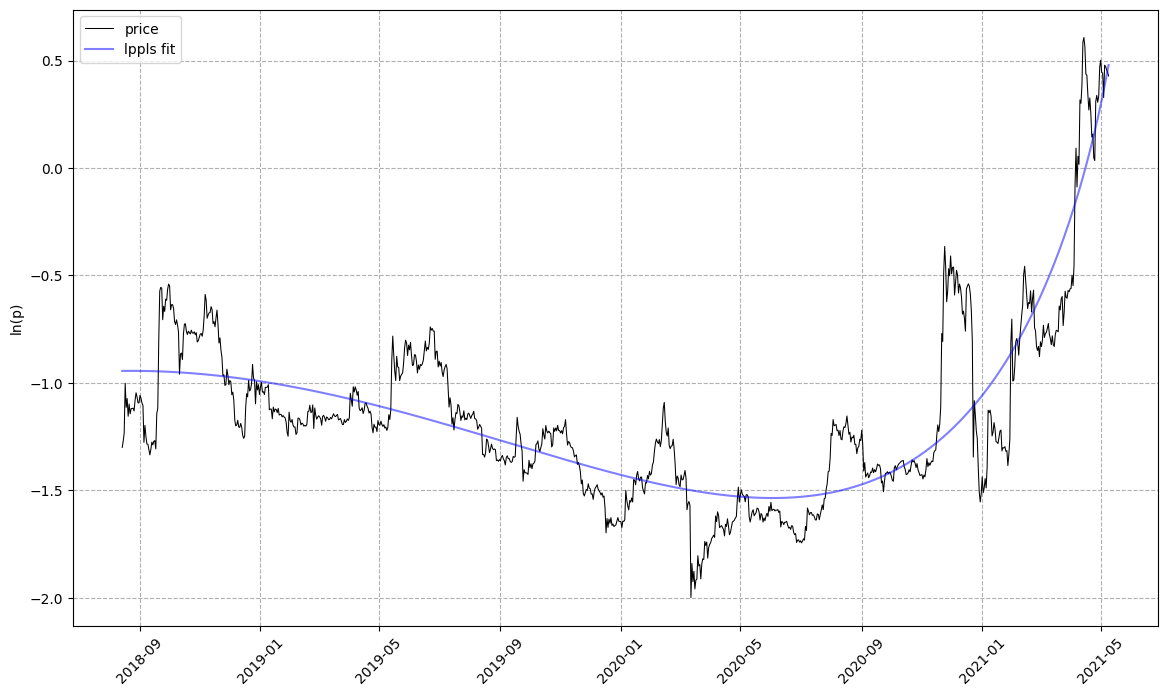

<Figure size 640x480 with 0 Axes>

In [ ]:
time_ord = [pd.Timestamp.fromordinal(d) for d in lppls_model.observations[0, :].astype('int32')]
t_obs = lppls_model.observations[0, :]
lppls_fit = [lppls_model.lppls(t, tc, m, w, a, b, c1, c2) for t in t_obs]
price = lppls_model.observations[1, :]

first = t_obs[0]
last = t_obs[-1]

fig, (ax1) = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=(14, 8))

ax1.plot(time_ord, price, label='price', color='black', linewidth=0.75)
ax1.plot(time_ord, lppls_fit, label='lppls fit', color='blue', alpha=0.5)
ax1.grid(which='major', axis='both', linestyle='--')
ax1.set_ylabel('ln(p)')
ax1.legend(loc=2)

plt.xticks(rotation=45)
plt.show()
plt.clf()

In [ ]:
res = lppls_model.mp_compute_nested_fits(
  workers=8,
  window_size=120,
  smallest_window_size=30,
  outer_increment=1,
  inner_increment=5,
  max_searches=MAX_SEARCHES
)

100%|██████████| 881/881 [27:07<00:00,  1.85s/it]


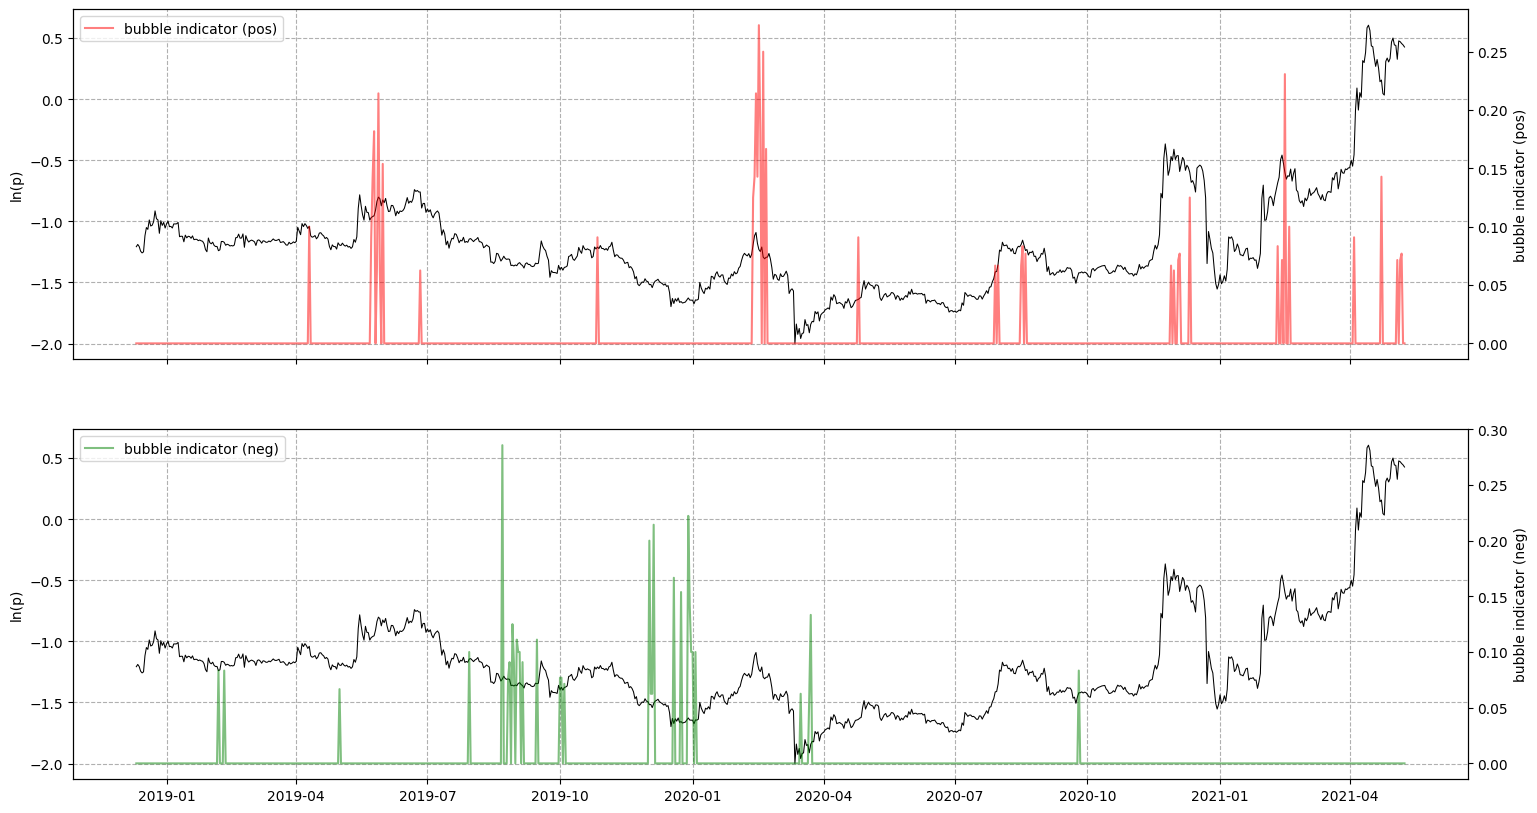

<Figure size 640x480 with 0 Axes>

In [ ]:
res_df = lppls_model.compute_indicators(res)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(18, 10))

ord = res_df['time'].astype('int32')
ts = [pd.Timestamp.fromordinal(d) for d in ord]

# plot pos bubbles
ax1_0 = ax1.twinx()
ax1.plot(ts, res_df['price'], color='black', linewidth=0.75)
ax1_0.plot(ts, res_df['pos_conf'], label='bubble indicator (pos)', color='red', alpha=0.5)

# plot neg bubbles
ax2_0 = ax2.twinx()
ax2.plot(ts, res_df['price'], color='black', linewidth=0.75)
ax2_0.plot(ts, res_df['neg_conf'], label='bubble indicator (neg)', color='green', alpha=0.5)

# set grids
ax1.grid(which='major', axis='both', linestyle='--')
ax2.grid(which='major', axis='both', linestyle='--')

# set labels
ax1.set_ylabel('ln(p)')
ax2.set_ylabel('ln(p)')

ax1_0.set_ylabel('bubble indicator (pos)')
ax2_0.set_ylabel('bubble indicator (neg)')

ax1_0.legend(loc=2)
ax2_0.legend(loc=2)

plt.xticks(rotation=45)
plt.show()
plt.clf()

In [ ]:
row_diff = len(data) - len(res_df)
pos_conf_arr = [0 for _ in range(row_diff)]
neg_conf_arr = [0 for _ in range(row_diff)]
pos_conf_arr.extend(res_df["pos_conf"].values)
neg_conf_arr.extend(res_df["neg_conf"].values)

data["bubble_pos_conf"] = pos_conf_arr
data["bubble_neg_conf"] = neg_conf_arr

data.set_index(date_text, inplace=True)
data.to_csv(f"output{TEST_FILE_NAME}.csv")
data.head()

,open,high,low,close,volume,bubble_pos_conf,bubble_neg_conf
date,,,,,,,
2018-08-14,0.27430,0.27732,0.24672,0.27250,56101899.0,0.0,0.0
2018-08-15,0.27280,0.30234,0.27280,0.28039,72676585.2,0.0,0.0
2018-08-16,0.28000,0.30184,0.27550,0.29142,46325561.5,0.0,0.0
2018-08-17,0.29161,0.37506,0.29085,0.36720,84683658.1,0.0,0.0
2018-08-18,0.36721,0.37000,0.31039,0.32829,80106581.6,0.0,0.0


In [3]:
import os

In [4]:
os.listdir("/content")

['.config', 'sample_data']

In [5]:
os.getcwd()

'/content'

In [10]:
os.listdir("/content/models/")

FileNotFoundError: [Errno 2] No such file or directory: '/content/models/'

In [11]:
!zip -r project_files.zip /content

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.05.06/ (stored 0%)
  adding: content/.config/logs/2026.05.06/13.29.14.541587.log (deflated 56%)
  adding: content/.config/logs/2026.05.06/13.28.49.988569.log (deflated 58%)
  adding: content/.config/logs/2026.05.06/13.29.01.464369.log (deflated 87%)
  adding: content/.config/logs/2026.05.06/13.28.31.781229.log (deflated 92%)
  adding: content/.config/logs/2026.05.06/13.29.03.081959.log (deflated 58%)
  adding: content/.config/logs/2026.05.06/13.29.13.739564.log (deflated 57%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: conten

In [12]:
from google.colab import files
files.download("project_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>